In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [51]:
dataset = load_iris()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [52]:
iris = pd.DataFrame(dataset.data,columns=dataset.feature_names)
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [53]:
target = pd.Series(dataset.target)
target.head()

,0
0,0
1,0
2,0
3,0
4,0


In [54]:
dataset.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

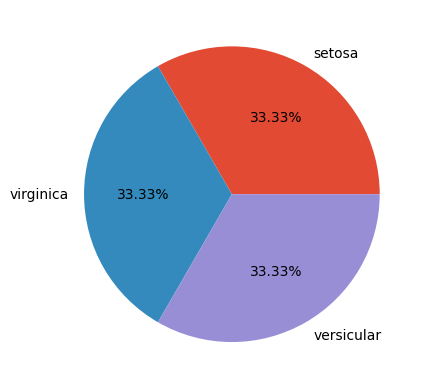

In [107]:
plt.style.use("ggplot")
plt.pie(target.value_counts(normalize=True),labels=['setosa','virginica','versicular'],autopct="%.2f%%")
plt.show()

In [93]:
def find_neighbour(k,x_train,test,labels):
  distances = np.sqrt(np.sum((x_train-test)**2,axis=1))
  distances_with_labels = np.stack([distances,labels.values],axis=1)
  top_k_distances =  pd.DataFrame(distances_with_labels,columns=["distance","label"]).sort_values(by="distance").iloc[:k].copy()
  return top_k_distances.value_counts(["label"]).sort_values(ascending=False).index[0]
  # return top_k_distances
def KNN(k,x_train,x_test,labels):
  y_pred = list()
  for test in x_test.values:
    label = find_neighbour(k,x_train,test,labels)
    y_pred.append(label[0])
  return pd.Series(y_pred)



In [104]:

X_train, X_test, y_train, y_test = train_test_split(iris, target,random_state=0)
y_pred = KNN(5,X_train,X_test,y_train)

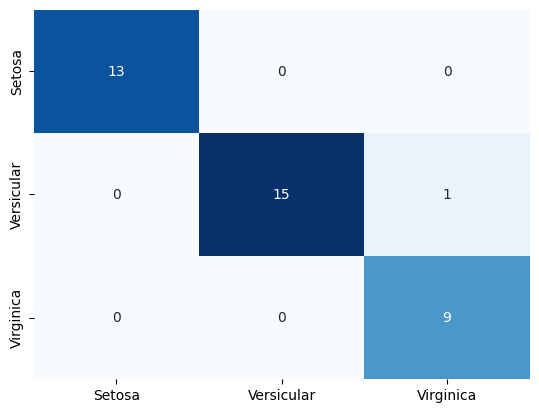

In [105]:
conf_matrix = confusion_matrix(y_pred=y_pred,y_true=y_test)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues,xticklabels=["Setosa","Versicular","Virginica"],yticklabels=["Setosa","Versicular","Virginica"])
plt.show()

In [106]:
report = classification_report(y_pred=y_pred,y_true=y_test,output_dict=True)
report = pd.DataFrame(report)
report

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.900000,0.973684,0.966667,0.976316
recall,1.0,0.937500,1.000000,0.973684,0.979167,0.973684
f1-score,1.0,0.967742,0.947368,0.973684,0.971703,0.973952
support,13.0,16.000000,9.000000,0.973684,38.000000,38.000000
